Suppose we are running an online business that sells groceries.  We want to create a table that represents the characteristics of the groceries.  Each item has a name; a price; a quantity purchased; a date of purchase; and a state in which it was purchased.

I am going to deliberately introduce null values, duplicate rows, and data values that don't make sense.  I will then pretend I don't know about these problems and write some code to detect them.

# Constructing Dataset (This wouldn't happen for real data, but can be used to test your ideas)

In [1]:
import random
import pandas as pd
from datetime import datetime
from datetime import timedelta
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
random.seed(0)

In [2]:
numrows = 100
grocery_names = ["apples_pound", "oranges_pound", "bananas_pound", "milk_gallon", "lettuce"]
df_groceries = pd.DataFrame({})
df_groceries["name"] = [random.choice(["apples_pound", "oranges_pound", "bananas_pound", "milk_gallon", "lettuce"]) for num in range(numrows)]
#np.random.choice(grocery_names, numrows)

In [3]:
def choose_unit_price(name):
    retval = None
    if(name == "apples_pound"):
        retval = random.uniform(1.00, 2.00)
    elif(name == "oranges_pound"):
        retval = random.uniform(2.00, 4.00)
    elif(name == "bananas_pound"):
        retval = random.uniform(1.00, 2.00)
    elif(name == "milk_gallon"):
        retval = random.uniform(3.00, 5.00)
    elif(name == "lettuce"):
        retval = random.uniform(1.50, 2.50)
    return np.round(retval, 2)

In [4]:
df_groceries["unit_price"] = df_groceries["name"].apply(choose_unit_price)
df_groceries["quantity"] = [random.randint(1, 5) for num in range(numrows)]

(array([18., 20., 24.,  9.,  4.,  6.,  5.,  5.,  4.,  5.]),
 array([1.02 , 1.409, 1.798, 2.187, 2.576, 2.965, 3.354, 3.743, 4.132,
        4.521, 4.91 ]),
 <BarContainer object of 10 artists>)

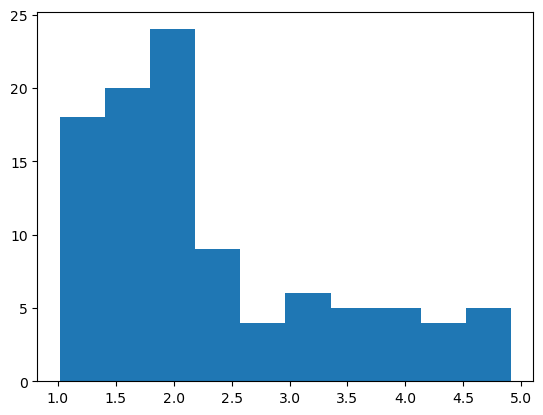

In [5]:
plt.hist(df_groceries.unit_price)

In [6]:
df_groceries

,name,unit_price,quantity
0,milk_gallon,3.55,1
1,milk_gallon,4.62,1
2,apples_pound,1.85,5
3,bananas_pound,1.90,2
4,lettuce,2.09,3
...,...,...,...
95,apples_pound,1.63,2
96,apples_pound,1.62,3
97,lettuce,2.22,3
98,milk_gallon,3.78,3


In [7]:
start = datetime(2020, 1, 1)
end = datetime(2026, 1, 1)
numdays = (end - start).days
random_days = np.random.randint(0, numdays, size = numrows)
df_groceries["date_purchased"] = start + pd.to_timedelta(random_days, unit='D')
df_groceries["state"] = [random.choice(["NY", "MA", "CA"]) for num in range(numrows)]

In [8]:
df_groceries

,name,unit_price,quantity,date_purchased,state
0,milk_gallon,3.55,1,2024-07-11,CA
1,milk_gallon,4.62,1,2022-04-15,NY
2,apples_pound,1.85,5,2022-02-02,MA
3,bananas_pound,1.90,2,2024-09-27,CA
4,lettuce,2.09,3,2022-10-30,NY
...,...,...,...,...,...
95,apples_pound,1.63,2,2020-11-03,MA
96,apples_pound,1.62,3,2023-01-09,MA
97,lettuce,2.22,3,2025-09-11,NY
98,milk_gallon,3.78,3,2023-04-21,CA


In [9]:
df_groceries.shape, numdays / 100

((100, 5), 21.92)

# Begin Data Cleaning and EDA

In [10]:
df_groceries

,name,unit_price,quantity,date_purchased,state
0,milk_gallon,3.55,1,2024-07-11,CA
1,milk_gallon,4.62,1,2022-04-15,NY
2,apples_pound,1.85,5,2022-02-02,MA
3,bananas_pound,1.90,2,2024-09-27,CA
4,lettuce,2.09,3,2022-10-30,NY
...,...,...,...,...,...
95,apples_pound,1.63,2,2020-11-03,MA
96,apples_pound,1.62,3,2023-01-09,MA
97,lettuce,2.22,3,2025-09-11,NY
98,milk_gallon,3.78,3,2023-04-21,CA


In [11]:
#df_groceries.groupby("name").unit_price.agg(["mean", "max", "min", "std"])

In [12]:
df_groceries.describe()

,unit_price,quantity,date_purchased
count,100.000000,100.000000,100
mean,2.305300,2.830000,2023-04-27 01:55:12
min,1.020000,1.000000,2020-03-25 00:00:00
25%,1.557500,1.750000,2021-10-16 00:00:00
50%,1.965000,3.000000,2023-03-31 12:00:00
75%,2.890000,4.000000,2025-03-23 18:00:00
max,4.910000,5.000000,2025-12-16 00:00:00
std,1.043878,1.421729,NaN


In [13]:
df_groceries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   name            100 non-null    object        
 1   unit_price      100 non-null    float64       
 2   quantity        100 non-null    int64         
 3   date_purchased  100 non-null    datetime64[ns]
 4   state           100 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 4.0+ KB


In [14]:
df_groceries.shape

(100, 5)

In [15]:
# Introducing "bugs"
df_groceries.loc[4, "state"] = np.nan # missing number / nan
df_groceries.loc[1, "unit_price"] = 1000000 # outlier / anomaly
df_groceries.loc[3, "state"] = "ZZ" # invalid
df_groceries.loc[2, "name"] = "television" # invalid

In [16]:
df_groceries

,name,unit_price,quantity,date_purchased,state
0,milk_gallon,3.55,1,2024-07-11,CA
1,milk_gallon,1000000.00,1,2022-04-15,NY
2,television,1.85,5,2022-02-02,MA
3,bananas_pound,1.90,2,2024-09-27,ZZ
4,lettuce,2.09,3,2022-10-30,NaN
...,...,...,...,...,...
95,apples_pound,1.63,2,2020-11-03,MA
96,apples_pound,1.62,3,2023-01-09,MA
97,lettuce,2.22,3,2025-09-11,NY
98,milk_gallon,3.78,3,2023-04-21,CA


In [17]:
#np.where(df_groceries.isna().sum(axis = 0) == 1)

In [18]:
# Detecting "bugs"
df_groceries.isna().sum(axis = 0)

name              0
unit_price        0
quantity          0
date_purchased    0
state             1
dtype: int64

In [19]:
arr = np.zeros(100, dtype = bool)
arr[4] = True
arr[3] = True
df_groceries[arr]

,name,unit_price,quantity,date_purchased,state
3,bananas_pound,1.90,2,2024-09-27,ZZ
4,lettuce,2.09,3,2022-10-30,NaN


In [20]:
for x in df_groceries.columns:
    print(x, df_groceries[df_groceries[x].isna()])

name Empty DataFrame
Columns: [name, unit_price, quantity, date_purchased, state]
Index: []
unit_price Empty DataFrame
Columns: [name, unit_price, quantity, date_purchased, state]
Index: []
quantity Empty DataFrame
Columns: [name, unit_price, quantity, date_purchased, state]
Index: []
date_purchased Empty DataFrame
Columns: [name, unit_price, quantity, date_purchased, state]
Index: []
state       name  unit_price  quantity date_purchased state
4  lettuce        2.09         3     2022-10-30   NaN


In [21]:
df_groceries.loc[10, "unit_price"] = "bad_value"
#df_groceries['unit_price'][0:12]
pd.to_numeric(df_groceries['unit_price'], errors='coerce')[0:12]

/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_62816/2770674302.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'bad_value' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_groceries.loc[10, "unit_price"] = "bad_value"


0           3.55
1     1000000.00
2           1.85
3           1.90
4           2.09
5           4.90
6           4.16
7           1.45
8           4.32
9           2.00
10           NaN
11          3.59
Name: unit_price, dtype: float64

In [22]:
np.where(pd.to_numeric(df_groceries['unit_price'], errors='coerce').notnull() == 0)

(array([10]),)

In [23]:
df_groceries.loc[10, "unit_price"] = "bad_value"
df_g2 = df_groceries[pd.to_numeric(df_groceries['unit_price'], errors='coerce').notnull()]
df_g2.iloc[0:11]

,name,unit_price,quantity,date_purchased,state
0,milk_gallon,3.55,1,2024-07-11,CA
1,milk_gallon,1000000.0,1,2022-04-15,NY
2,television,1.85,5,2022-02-02,MA
3,bananas_pound,1.9,2,2024-09-27,ZZ
4,lettuce,2.09,3,2022-10-30,NaN
5,milk_gallon,4.9,2,2020-10-04,NY
6,milk_gallon,4.16,2,2024-11-13,MA
7,bananas_pound,1.45,2,2025-01-02,NY
8,milk_gallon,4.32,4,2021-12-06,NY
9,bananas_pound,2.0,4,2025-11-05,CA


In [24]:
df_g2.groupby("state").unit_price.mean()

state
CA        2.042917
MA        2.679722
NY    27029.027027
ZZ             1.9
Name: unit_price, dtype: object

In [25]:
df_groceries.groupby("state").size()

state
CA    24
MA    37
NY    37
ZZ     1
dtype: int64

In [26]:
df_g2.groupby("state").agg({"unit_price": "max", "quantity": "max", "date_purchased": "max"})

,unit_price,quantity,date_purchased
state,,,
CA,3.78,5,2025-12-16
MA,4.91,5,2025-10-21
NY,1000000.0,5,2025-12-16
ZZ,1.9,2,2024-09-27


In [27]:
df_groceries[df_groceries["state"] != "ZZ"].groupby("state").size()

state
CA    24
MA    37
NY    37
dtype: int64

In [28]:
unit_price = np.array([x for x in df_groceries["unit_price"] if not isinstance(x, str)])

In [29]:
np.histogram(unit_price, bins = 3)

(array([98,  0,  1]),
 array([1.02000000e+00, 3.33334013e+05, 6.66667007e+05, 1.00000000e+06]))

In [30]:
unit_price_fixed = unit_price[unit_price < 10]

In [31]:
np.histogram(unit_price_fixed)

(array([18, 20, 24,  8,  4,  6,  5,  5,  4,  4]),
 array([1.02 , 1.409, 1.798, 2.187, 2.576, 2.965, 3.354, 3.743, 4.132,
        4.521, 4.91 ]))

# Graph presentation

(array([18., 20., 24.,  8.,  4.,  6.,  5.,  5.,  4.,  4.]),
 array([1.02 , 1.409, 1.798, 2.187, 2.576, 2.965, 3.354, 3.743, 4.132,
        4.521, 4.91 ]),
 <BarContainer object of 10 artists>)

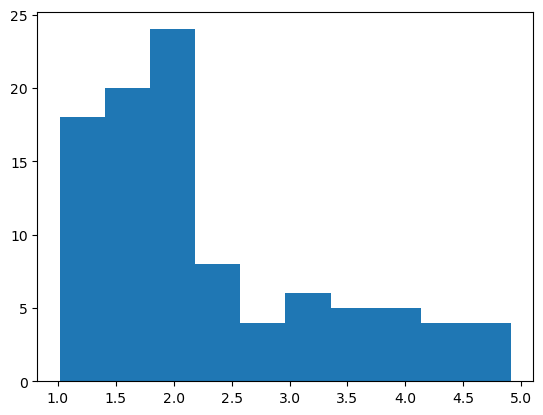

In [32]:
import matplotlib.pyplot as plt
plt.hist(unit_price_fixed)

(array([38., 32., 10., 10.,  8.]),
 array([1.02 , 1.798, 2.576, 3.354, 4.132, 4.91 ]),
 <BarContainer object of 5 artists>)

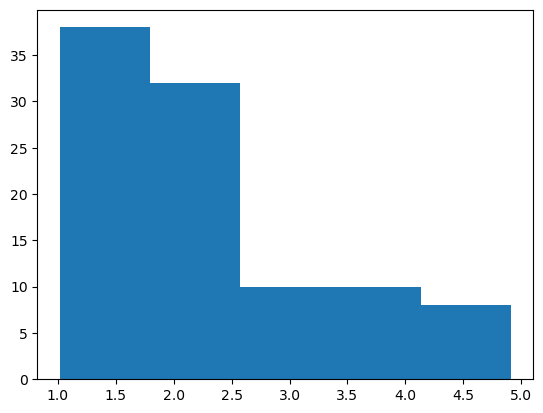

In [33]:
plt.hist(unit_price_fixed, bins = 5)

(array([11.,  7., 11.,  9., 15.,  9.,  5.,  3.,  3.,  1.,  1.,  5.,  1.,
         4.,  4.,  1.,  3.,  1.,  1.,  3.]),
 array([1.02  , 1.2145, 1.409 , 1.6035, 1.798 , 1.9925, 2.187 , 2.3815,
        2.576 , 2.7705, 2.965 , 3.1595, 3.354 , 3.5485, 3.743 , 3.9375,
        4.132 , 4.3265, 4.521 , 4.7155, 4.91  ]),
 <BarContainer object of 20 artists>)

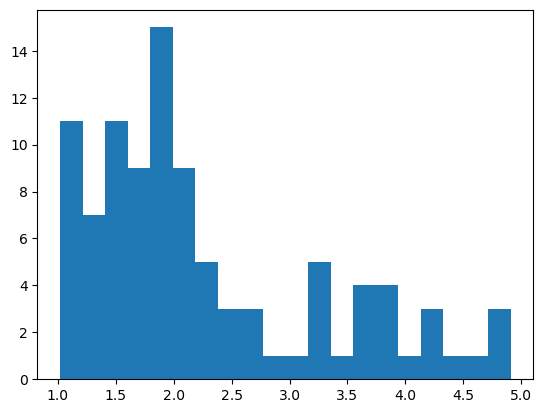

In [34]:
plt.hist(unit_price_fixed, bins = 20)

(array([0.57709459, 0.36724201, 0.57709459, 0.4721683 , 0.78694717,
        0.4721683 , 0.26231572, 0.15738943, 0.15738943, 0.05246314,
        0.05246314, 0.26231572, 0.05246314, 0.20985258, 0.20985258,
        0.05246314, 0.15738943, 0.05246314, 0.05246314, 0.15738943]),
 array([1.02  , 1.2145, 1.409 , 1.6035, 1.798 , 1.9925, 2.187 , 2.3815,
        2.576 , 2.7705, 2.965 , 3.1595, 3.354 , 3.5485, 3.743 , 3.9375,
        4.132 , 4.3265, 4.521 , 4.7155, 4.91  ]),
 <BarContainer object of 20 artists>)

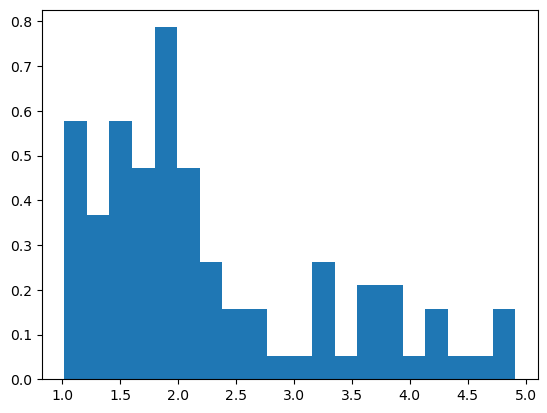

In [35]:
plt.hist(unit_price_fixed, bins = 20, density = True)

(array([0.1122449 , 0.18367347, 0.29591837, 0.3877551 , 0.54081633,
        0.63265306, 0.68367347, 0.71428571, 0.74489796, 0.75510204,
        0.76530612, 0.81632653, 0.82653061, 0.86734694, 0.90816327,
        0.91836735, 0.94897959, 0.95918367, 0.96938776, 1.        ]),
 array([1.02  , 1.2145, 1.409 , 1.6035, 1.798 , 1.9925, 2.187 , 2.3815,
        2.576 , 2.7705, 2.965 , 3.1595, 3.354 , 3.5485, 3.743 , 3.9375,
        4.132 , 4.3265, 4.521 , 4.7155, 4.91  ]),
 <BarContainer object of 20 artists>)

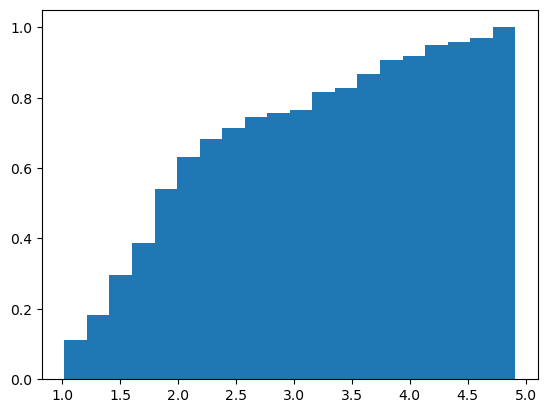

In [36]:
plt.hist(unit_price_fixed, bins = 20, density = True, cumulative = True)

In [37]:
np.sort(unit_price)[-5:]

array([4.68e+00, 4.87e+00, 4.90e+00, 4.91e+00, 1.00e+06])

In [38]:
np.sort(unit_price)[np.sort(unit_price) < 5][-5:]

array([4.4 , 4.68, 4.87, 4.9 , 4.91])

In [39]:
df_groceries.groupby("name").size()

name
apples_pound     19
bananas_pound    20
lettuce          26
milk_gallon      17
oranges_pound    17
television        1
dtype: int64

In [40]:
df_type = df_groceries.map(type)
for col in df_type.columns:
    print(col, df_type[col].unique())

name [<class 'str'>]
unit_price [<class 'float'> <class 'str'>]
quantity [<class 'int'>]
date_purchased [<class 'pandas._libs.tslibs.timestamps.Timestamp'>]
state [<class 'str'> <class 'float'>]


In [41]:
np.where([isinstance(x, str) for x in df_groceries.unit_price])

(array([10]),)

In [42]:
np.where([isinstance(x, float) for x in df_groceries.state])

(array([4]),)

In [43]:
df_groceries_fixed = df_groceries[np.vectorize(lambda x: isinstance(x, float) and  x < 10)(df_groceries["unit_price"])]

In [44]:
df_groceries_fixed[["unit_price", "quantity", "date_purchased"]].mean(axis = 0)

unit_price                              2.28051
quantity                               2.826531
date_purchased    2023-04-25 22:31:50.204081664
dtype: object